In [52]:
import pandas as pd

resdir = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/fp_decomp_kde/fp_decomp_testing_pipeline/results"
df = pd.read_csv(f"{resdir}/metrics.csv", index_col=0)


# Remove non-gaussian distributions
df_1 = df[df["kl_div"] < 0.5]

# Remove non-correlating decomp distances with tanimoto distances (pearsonr < 0.4)
df_2 = df_1[df_1["pearsonr"].apply(lambda x: True if abs(x) > 0.4 else False)]

# Remove unstable: highly perturbted by noise (noise pert > 0.3)
df_3 = df_2[df_2["noise_pert"].apply(lambda x: True if x < 0.3 else False)]

# Remove low information or high intrinsic dimensions (MLE or twoNN is 1 or >> 10)
df_4 = df_3.drop([29, 30, 24, 4, 5])

# Any other things to notice
df_5 = df_4.drop([10])

df_5

,fingerprint,decomp,skew_1,skew_2,kurtosis_1,kurtosis_2,kl_div,spearmanr,spearmanp,pearsonr,...,noise_pert,outlier_mean_shift,kde_mean_shift,butina_mean_shift,avg_cluster_size,max_cluster_size,min_cluster_size,cluster_overlap,twoNN,MLE
0,morgan_ECFP4_2048,pca,0.229592,-0.231615,-1.196654,-0.789013,0.360864,-0.603550,0.0,-0.495405,...,0.124048,0.034066,0.020173,0.000898,181.818182,259,1,0.178436,6,12.791726
1,morgan_ECFP4_2048,pca_rbf,0.227969,0.228425,-1.197562,-0.794180,0.361248,-0.579539,0.0,-0.478128,...,0.108393,0.033425,0.013043,0.001363,200.000000,350,1,0.144568,6,12.791726
11,atom_pair_2048,isomap,0.203681,-0.049153,-1.064892,-0.549954,0.250035,-0.650422,0.0,-0.606445,...,0.171804,0.014476,0.010572,0.020552,222.222222,315,19,0.127901,26,10.302275
12,atom_pair_2048,umap,0.135807,-0.191160,-0.920192,-0.173558,0.454230,-0.650675,0.0,-0.615219,...,0.239994,0.035115,0.017560,0.016570,181.818182,260,2,0.271655,26,10.302275
25,avalon_512,pca_rbf,0.353713,0.362446,-0.724704,-0.359869,0.444786,-0.438756,0.0,-0.504627,...,0.052899,0.050928,0.057984,0.025851,200.000000,422,31,0.158372,2,6.969033


In [55]:
df_5.index = [i+"_"+j for i,j in zip(df_5["fingerprint"], df_5["decomp"])]
df_5.T

,morgan_ECFP4_2048_pca,morgan_ECFP4_2048_pca_rbf,atom_pair_2048_isomap,atom_pair_2048_umap,avalon_512_pca_rbf
fingerprint,morgan_ECFP4_2048,morgan_ECFP4_2048,atom_pair_2048,atom_pair_2048,avalon_512
decomp,pca,pca_rbf,isomap,umap,pca_rbf
skew_1,0.229592,0.227969,0.203681,0.135807,0.353713
skew_2,-0.231615,0.228425,-0.049153,-0.19116,0.362446
kurtosis_1,-1.196654,-1.197562,-1.064892,-0.920192,-0.724704
kurtosis_2,-0.789013,-0.79418,-0.549954,-0.173558,-0.359869
kl_div,0.360864,0.361248,0.250035,0.45423,0.444786
spearmanr,-0.60355,-0.579539,-0.650422,-0.650675,-0.438756
spearmanp,0.0,0.0,0.0,0.0,0.0
pearsonr,-0.495405,-0.478128,-0.606445,-0.615219,-0.504627


In [60]:
resdir = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/fp_decomp_kde/fp_decomp_testing_pipeline/results_selected_sample_8992"
df = pd.read_csv(f"{resdir}/metrics.csv", index_col=0)

df.index = [i+"_"+j for i,j in zip(df["fingerprint"], df["decomp"])]
df.T

,atom_pair_2048_isomap,morgan_ECFP4_2048_pca_rbf
fingerprint,atom_pair_2048,morgan_ECFP4_2048
decomp,isomap,pca_rbf
skew_1,0.184067,0.131666
skew_2,0.202166,0.100394
kurtosis_1,-0.923323,-1.052141
kurtosis_2,-0.575854,-0.534551
kl_div,0.14198,0.326253
spearmanr,-0.513932,-0.460954
spearmanp,0.0,0.0
pearsonr,-0.508885,-0.442088


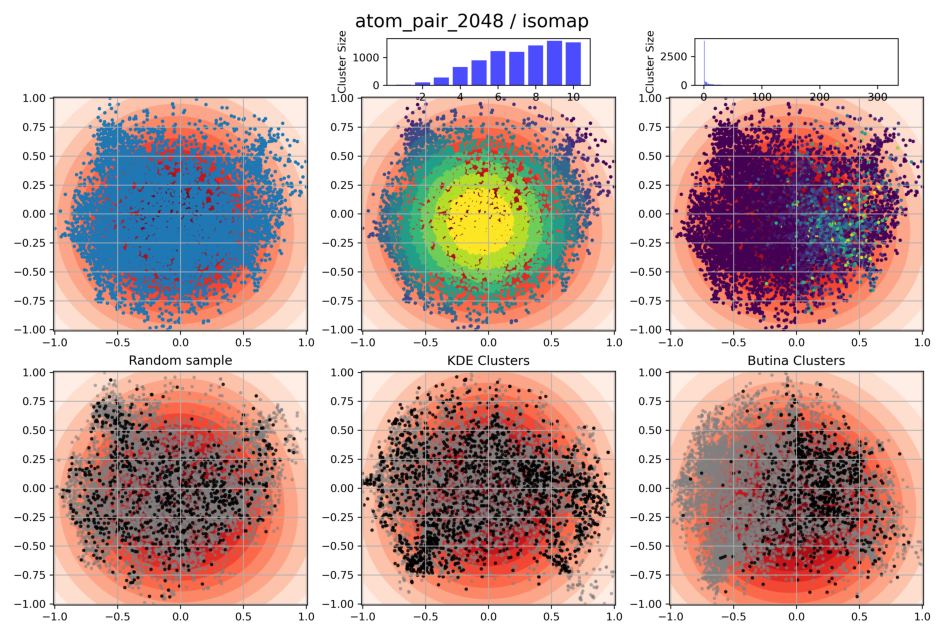

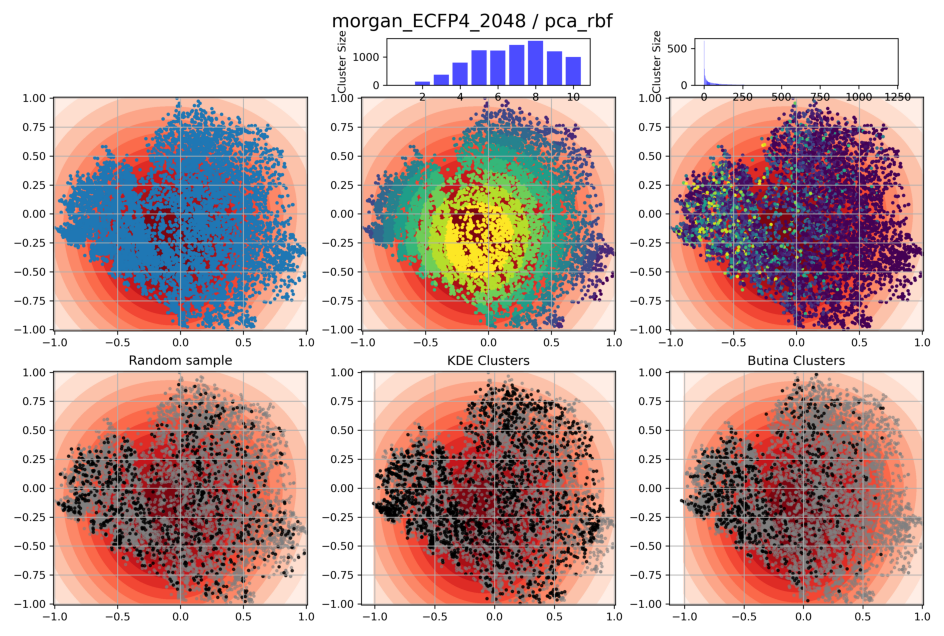

In [61]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for col in df.T.columns:
    # Load an image using matplotlib
    img = mpimg.imread(resdir + "/" + col + ".png")

    fig, ax = plt.subplots(figsize=(12, 8))
    # Display the image
    ax.imshow(img)
    ax.axis('off')  # Hide axes
    plt.show()